In [3]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [4]:
manual_db = pl.read_parquet(r".database\manual_detection_database.parquet")
auto_db = dp.combined_mask_no_merge.filter(pl.col("face") == "posx").collect()

manual_db

i,j,manual_detect_boulder_id,face
i32,i32,u32,str
7661,5626,7883757,"""posx"""
7661,5627,7883757,"""posx"""
7661,5628,7883757,"""posx"""
7661,5629,7883757,"""posx"""
7661,5630,7883757,"""posx"""
…,…,…,…
40,2454,10549449,"""posx"""
40,2455,10549449,"""posx"""
40,2456,10549449,"""posx"""


In [5]:
auto_db_agg = auto_db.group_by("row_id").agg(pl.len().alias("auto_boulder_size"))
manual_db_agg = manual_db.group_by("manual_detect_boulder_id").agg(pl.len().alias("manual_boulder_size"))

db_intersections = manual_db.join(
    auto_db,
    on=["i", "j"],
    how="inner",
).select("i", "j", "lod_level", "lod_code", "row_id", "manual_detect_boulder_id")

manual_db_agg

manual_detect_boulder_id,manual_boulder_size
u32,u32
2414365,238
7324622,54999
12973782,55
1411612,58
8143751,16019
…,…
14149024,202
16263207,458
1463622,9


In [6]:
db_intersections_agg = db_intersections.group_by("manual_detect_boulder_id", "row_id").agg(
    pl.len().alias("overlap"),
    pl.col("lod_level").first(),
    pl.col("lod_code").first()
)

db_jaccard = db_intersections_agg.join(
    auto_db_agg,
    on="row_id",
    how="left",
).join(
    manual_db_agg,
    on="manual_detect_boulder_id",
    how="left",
).with_columns(
    (
        pl.col("overlap") / (pl.col("auto_boulder_size") + pl.col("manual_boulder_size") - pl.col("overlap"))
    ).alias("Jaccard_index")
)

db_jaccard

manual_detect_boulder_id,row_id,overlap,lod_level,lod_code,auto_boulder_size,manual_boulder_size,Jaccard_index
u32,u32,u32,u8,str,u32,u32,f64
10549449,6,15997,0,"""""",17152,21584,0.703505
15932283,19601,2048,1,"""A""",2048,248654,0.008236
6022541,976122,173,1,"""B""",1856,65088,0.002591
14583345,45,35945,0,"""""",38656,40655,0.828875
566518,1096486,5,4,"""BABD""",33,68617,0.000073
…,…,…,…,…,…,…,…
7491885,2383385,32,4,"""CBDA""",32,63106,0.000507
5535880,2383587,78,4,"""CBDA""",80,120,0.639344
1204414,2406173,101,4,"""CBDB""",267,30911,0.00325


In [7]:
db_jaccard_agg = (
    db_jaccard
    .group_by(["lod_level", "manual_detect_boulder_id"])
    .agg(
        pl.all().get(
            pl.col("Jaccard_index").arg_max()
        )
    )
).with_columns(
    (pl.col("manual_boulder_size") // (2 ** (8 - 2 * pl.col("lod_level")))).alias("viewport_size"),
    (pl.col("auto_boulder_size") / pl.col("manual_boulder_size")).alias("area_diff_factor")
)

db_jaccard_agg

lod_level,manual_detect_boulder_id,row_id,overlap,lod_code,auto_boulder_size,manual_boulder_size,Jaccard_index,viewport_size,area_diff_factor
u8,u32,u32,u32,str,u32,u32,f64,u32,f64
4,333506,1858965,53,"""BDCD""",59,80,0.616279,80,0.7375
4,3485687,751160,261,"""ADAA""",261,56663,0.004606,56663,0.004606
4,195594,1633932,229,"""BCDA""",243,296,0.73871,296,0.820946
3,1214942,1762145,759,"""BDB""",1220,932,0.544867,233,1.309013
4,2961614,1203540,50,"""BADD""",51,87,0.568182,87,0.586207
…,…,…,…,…,…,…,…,…,…
4,16325726,1415211,65,"""BBDC""",66,124,0.52,124,0.532258
1,15234118,1924104,63229,"""C""",74432,79858,0.694359,1247,0.932054
2,1735651,2178569,866,"""CB""",1200,959,0.66976,59,1.251303


In [8]:
from sklearn.neighbors import KernelDensity

db_jaccard_agg_filter = db_jaccard_agg.filter(pl.col("viewport_size") > 0)
alphas = db_jaccard_agg_filter["viewport_size"].to_numpy()
j = db_jaccard_agg_filter["Jaccard_index"].to_numpy()

plotting_alphas = np.geomspace(1, 512**2, 500)
plotting_alphas_log = np.log(plotting_alphas)

def get_s_KDE(j_min, alpha_inputs : np.ndarray, bootstrap = False, bw_method=0.1):
    alphas_pass = alphas[j > j_min]

    log_alphas = np.log(alphas)
    log_alphas_pass = np.log(alphas_pass)

    if bootstrap:
        log_alphas = np.random.choice(log_alphas, size=len(log_alphas), replace=True)
        log_alphas_pass = np.random.choice(log_alphas_pass, size=len(log_alphas_pass), replace=True)

    # log_alphas_kde = lambda alpha : len(log_alphas) * gaussian_kde(log_alphas, bw_method=bw_method)(np.log(alpha)) / alpha
    # log_alphas_pass_kde = lambda alpha : len(log_alphas_pass) * gaussian_kde(log_alphas_pass, bw_method = bw_method)(np.log(alpha)) / alpha

    # Fit the KDEs
    kde_log_alphas = KernelDensity(
        kernel="epanechnikov",
        bandwidth=bw_method
    ).fit(log_alphas[:, None])

    kde_log_alphas_pass = KernelDensity(
        kernel="epanechnikov",
        bandwidth=bw_method
    ).fit(log_alphas_pass[:, None])

    # Equivalent functions
    log_alphas_kde = lambda alpha: (
        len(log_alphas)
        * np.exp(kde_log_alphas.score_samples(np.log(alpha).reshape(-1, 1)))
        / alpha
    )

    log_alphas_pass_kde = lambda alpha: (
        len(log_alphas_pass)
        * np.exp(kde_log_alphas_pass.score_samples(np.log(alpha).reshape(-1, 1)))
        / alpha
    )

    return np.divide(
        log_alphas_pass_kde(alpha_inputs),
        log_alphas_kde(alpha_inputs),
        out=np.zeros_like(alpha_inputs, dtype=float),
        where=log_alphas_kde(alpha_inputs) != 0
    )
    

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.0s finished


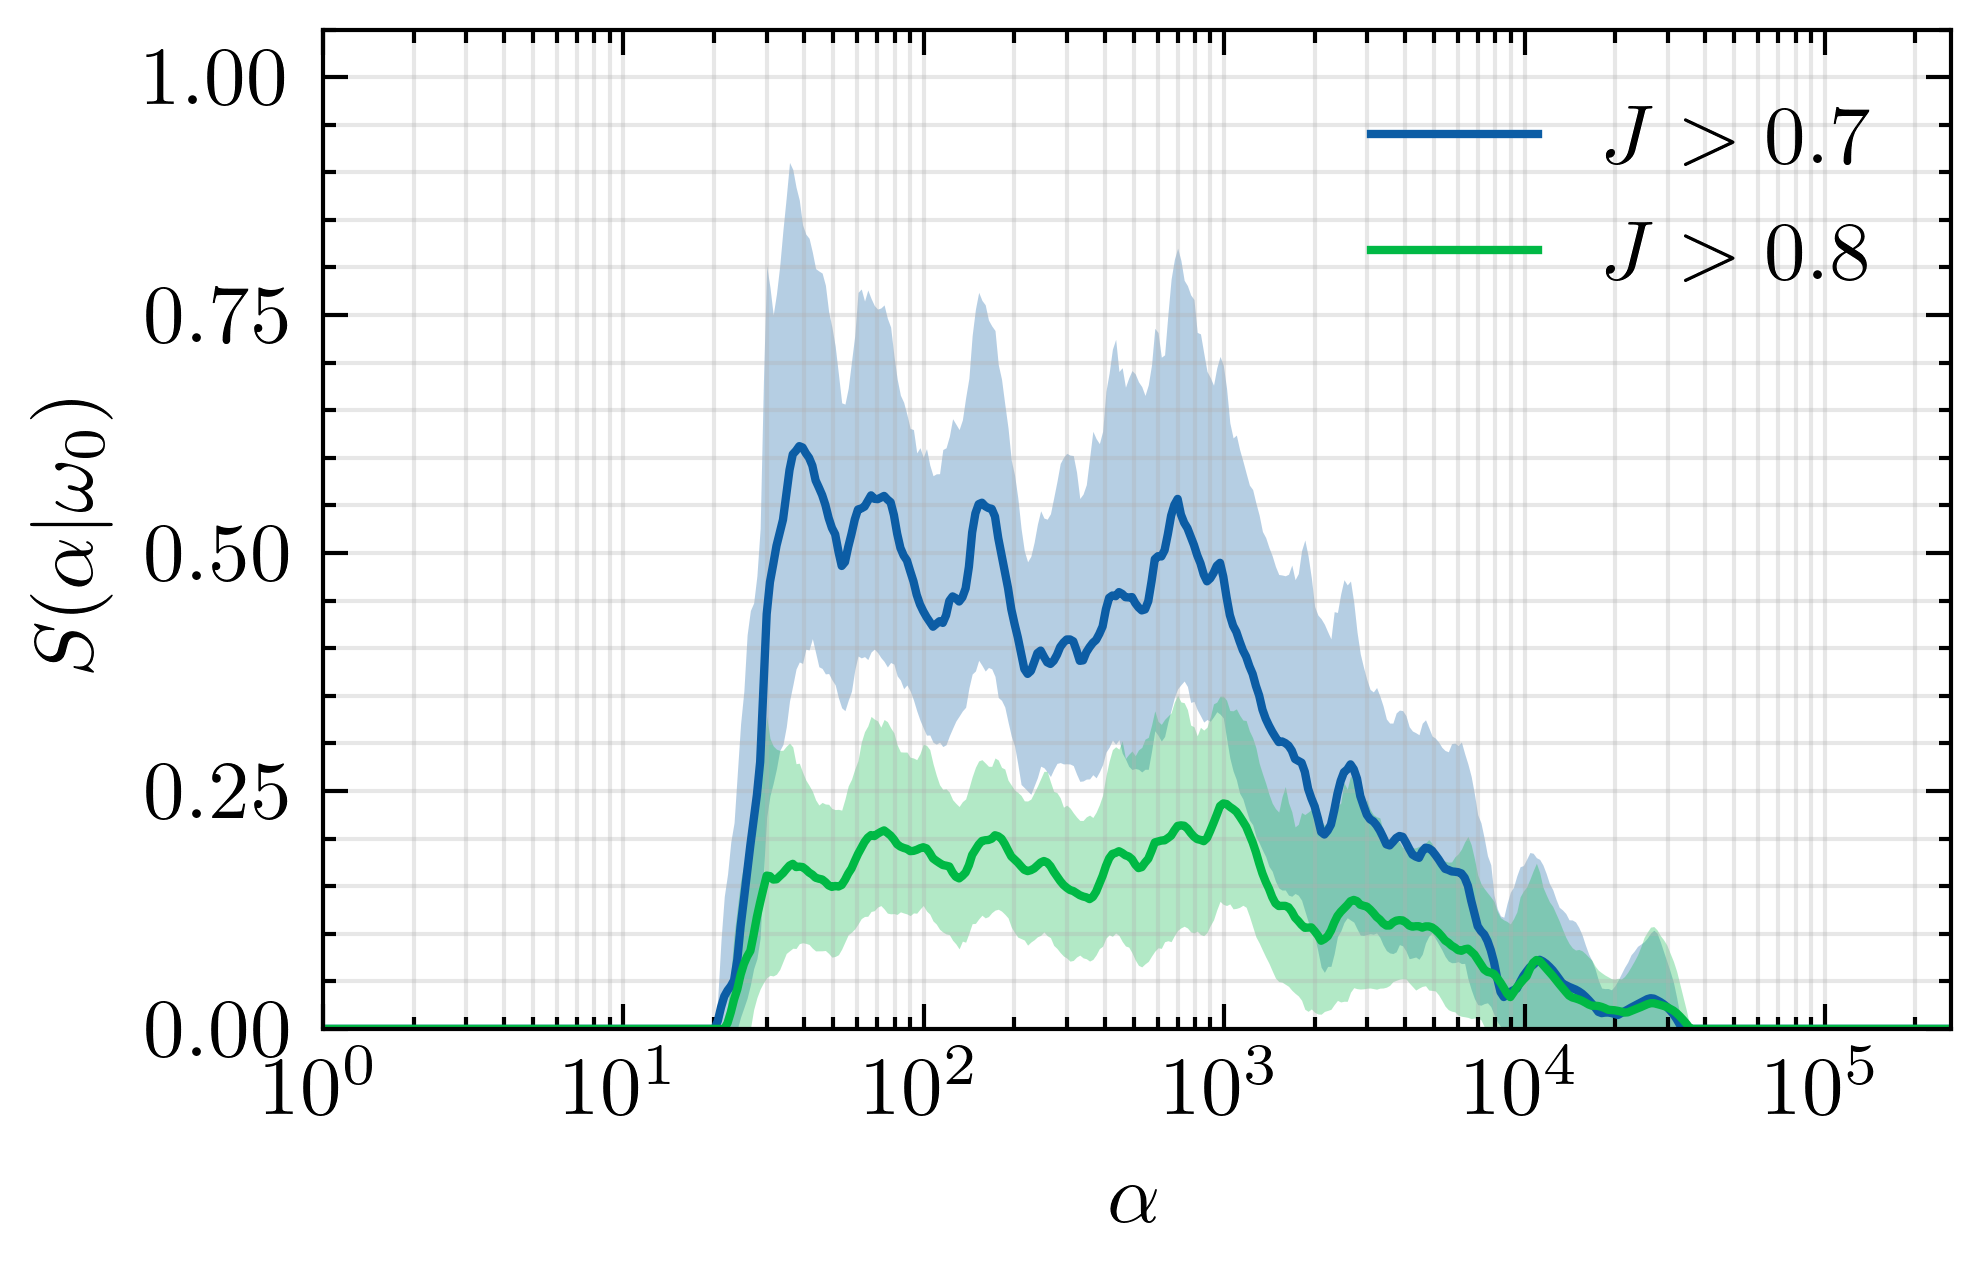

In [15]:
from joblib import Parallel, delayed

# 200 for normal runs 5_000 for publication
numb_bootstrap = 200
plotting_alphas = np.geomspace(1, 512**2, 500)

for c_code, j_min_plot in enumerate([0.7, 0.8]):
    
    bootstrap_kde_data = np.array(
        Parallel(n_jobs=-1, verbose = 1)(
            delayed(get_s_KDE)(
                j_min_plot,
                plotting_alphas,
                True,
                "scott"
            )
            for _ in range(numb_bootstrap)
        )
    ).T

    # Statistics
    mean_pdf = bootstrap_kde_data.mean(axis=1)
    lower = np.percentile(bootstrap_kde_data, 2.5, axis=1)
    upper = np.percentile(bootstrap_kde_data, 97.5, axis=1)

    # 95% confidence interval
    plt.fill_between(
        plotting_alphas, lower, upper,
        alpha=0.3,
        color= f"C{c_code}",
        linewidth = 0
    )

    # Mean bootstrap KsDE
    plt.plot(plotting_alphas, mean_pdf, label=rf"$J > {j_min_plot}$", c = f"C{c_code}")

plt.xscale("log")
# plt.yscale("log")
plt.ylim(0, 1.05)
plt.xlim(1, 512*512)
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$S(\alpha|\omega_0)$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.savefig("S_from_manual_detection.png")
plt.show()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 404 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 1404 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 2804 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 4604 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done 4957 out of 5000 | elapsed:    9.5s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    9.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 22 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 404 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 1404 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 2804 tasks      | elapsed:    6.0s
[Parallel(n_jobs=-1)]: Done 4604 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 4957 out of 5000 | elapsed:   10.8s 

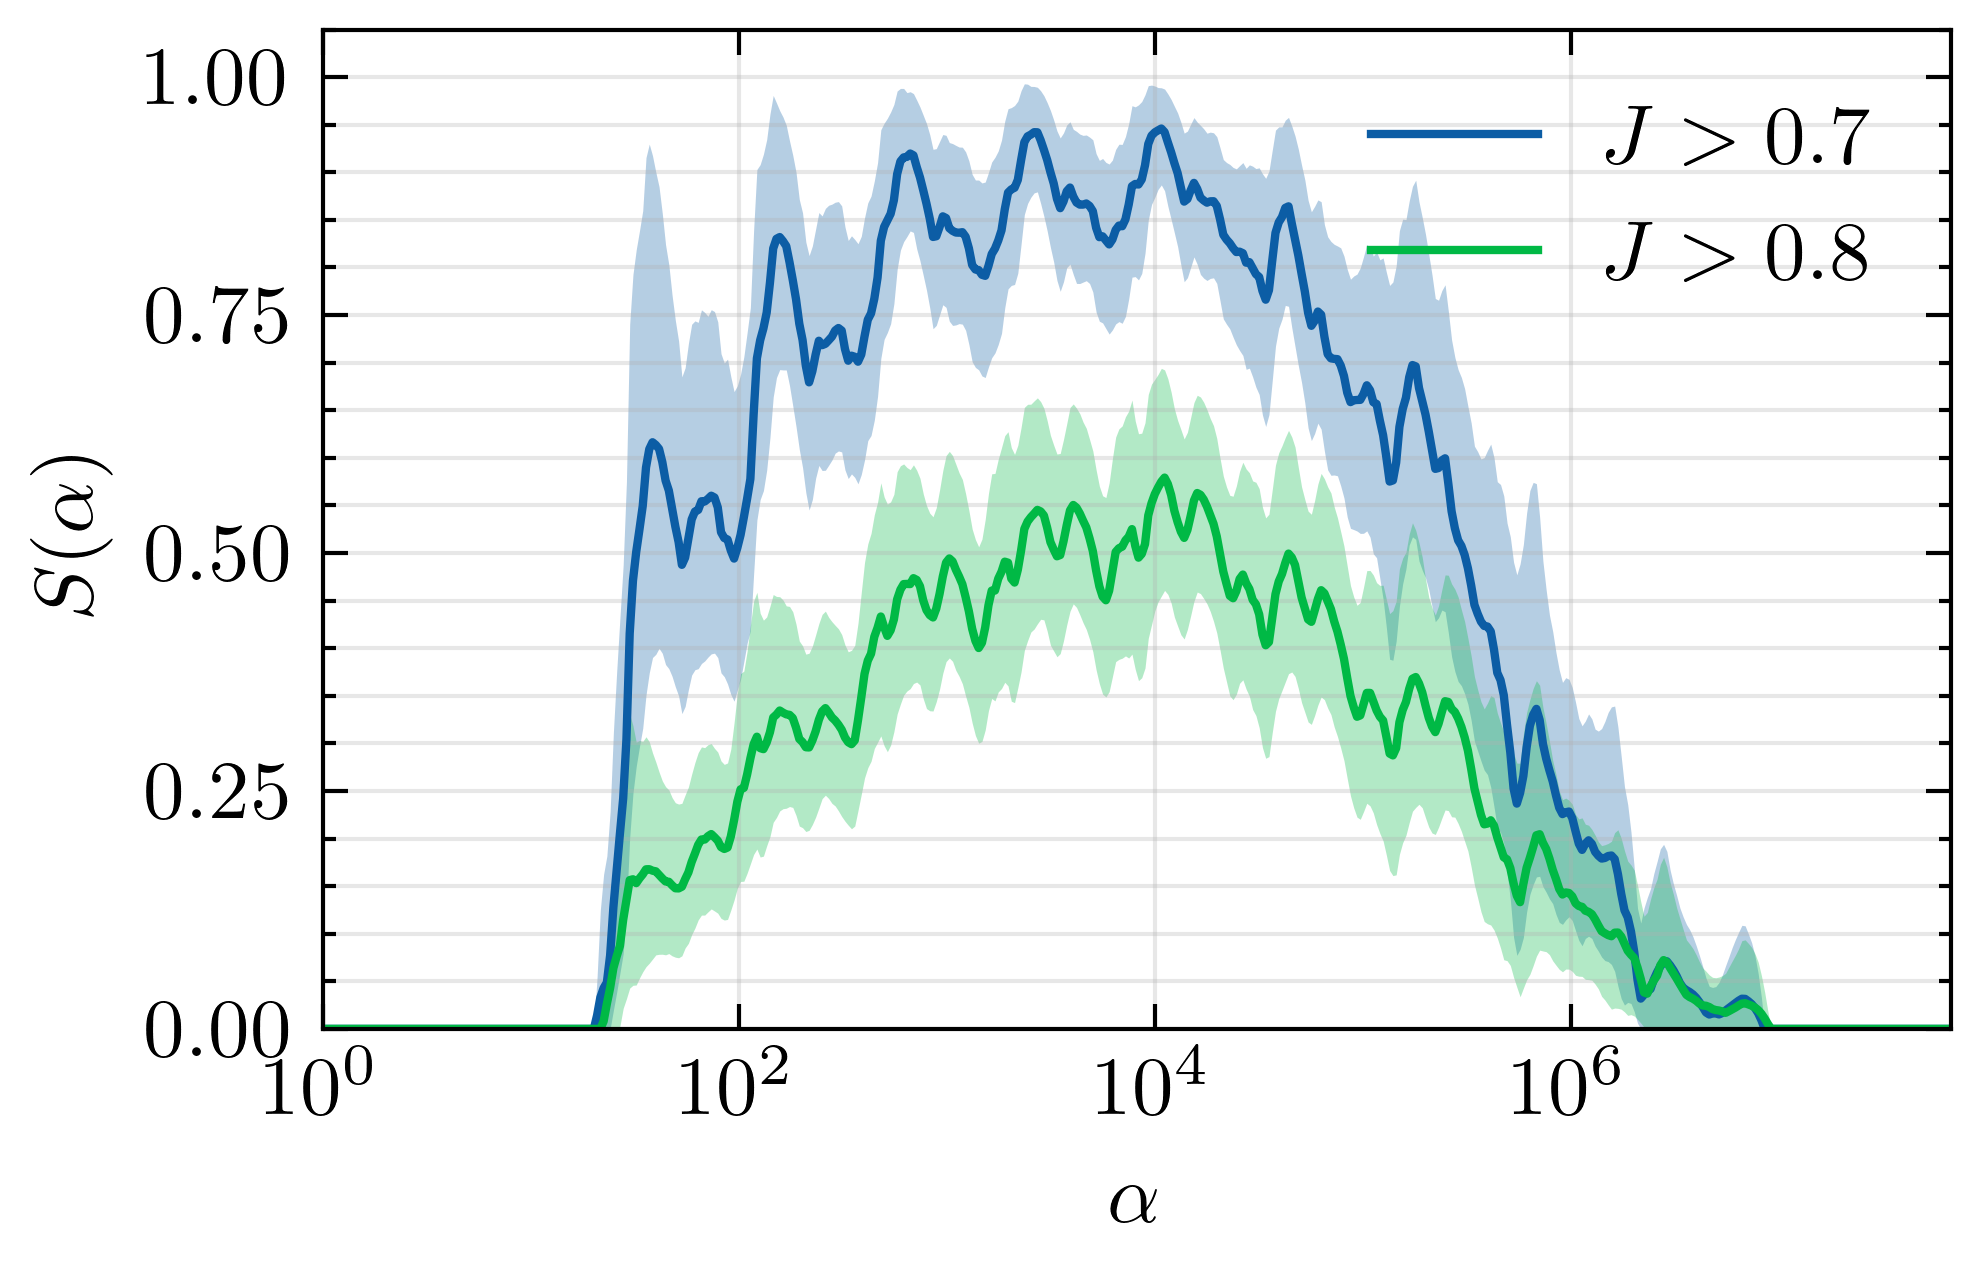

In [ ]:
from joblib import Parallel, delayed

# 200 for normal runs 5_000 for publication
numb_bootstrap = 5_000
plotting_alphas = np.geomspace(1, 2 ** (2 * 4) * 512**2, 500)

def get_s_alpha_KDE(j_min: float,
    alpha_inputs: np.ndarray,
    bootstrap: bool = False,
    bw_method: float = 0.1):
    return 1 - np.prod([
            1 - get_s_KDE(j_min, alpha_inputs / (2 ** (2 * 4 - 2 * i)), bootstrap, bw_method) for i in range(5)
        ], axis=0)

for c_code, j_min_plot in enumerate([0.7, 0.8]):
    
    bootstrap_kde_data = np.array(
        Parallel(n_jobs=-1, verbose = 1)(
            delayed(get_s_alpha_KDE)(
                j_min_plot,
                plotting_alphas,
                True,
                "scott"
            )
            for _ in range(numb_bootstrap)
        )
    ).T

    # Statistics
    mean_pdf = bootstrap_kde_data.mean(axis=1)
    lower = np.percentile(bootstrap_kde_data, 2.5, axis=1)
    upper = np.percentile(bootstrap_kde_data, 97.5, axis=1)

    # 95% confidence interval
    plt.fill_between(
        plotting_alphas, lower, upper,
        alpha=0.3,
        color= f"C{c_code}",
        linewidth = 0
    )

    # Mean bootstrap KsDE
    plt.plot(plotting_alphas, mean_pdf, label=rf"$J > {j_min_plot}$", c = f"C{c_code}")

plt.xscale("log")
# plt.yscale("log")
plt.ylim(0, 1.05)
plt.xlim(1, plotting_alphas.max())
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$S(\alpha)$")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.savefig("S_alpha_from_manual_detection.png")
plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# db_jaccard_agg_filter = db_jaccard_agg.filter(pl.col("viewport_size") > 0)
# alphas = db_jaccard_agg_filter["viewport_size"].to_numpy()
# j = db_jaccard_agg_filter["Jaccard_index"].to_numpy()

# auto_alphas = dp.boulder_agg_data.collect().with_columns(
#     (pl.col("alpha") // (2 ** (8 - 2 * pl.col("lod_level")))).alias("viewport_size")
# )["viewport_size"]

# plotting_alphas = np.geomspace(1, 512**2, 500)
# plotting_alphas_log = np.log(plotting_alphas)

# alphas_pass = alphas[j > 0.7]

# log_alphas = np.log(alphas)
# log_alphas_pass = np.log(alphas_pass)
# # log_auto_alphas = np.log(auto_alphas)

# log_alphas_kde = lambda alpha : len(log_alphas) * gaussian_kde(log_alphas)(np.log(alpha)) / alpha
# log_alphas_pass_kde = lambda alpha : len(log_alphas_pass) * gaussian_kde(log_alphas_pass)(np.log(alpha)) / alpha
# # log_auto_alphas_kde = lambda alpha : len(log_auto_alphas) * gaussian_kde(log_auto_alphas, bw_method = 0.01)(np.log(alpha)) / alpha

# plt.plot(plotting_alphas, log_alphas_kde(plotting_alphas), label="Total KDE")
# plt.plot(plotting_alphas, log_alphas_pass_kde(plotting_alphas), label="Success KDE")
# plt.xscale("log")
# plt.xlabel("Viewport size")
# plt.ylabel("Density")
# plt.legend()
# plt.show()